In [1]:
# Project-relative paths: no machine-specific absolute paths are required.
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
for _candidate in (PROJECT_ROOT, *PROJECT_ROOT.parents):
    if (_candidate / "workspace" / "Source_Data.xlsx").exists():
        PROJECT_ROOT = _candidate
        break
else:
    raise FileNotFoundError(
        "workspace/Source_Data.xlsx was not found. Run the notebook from inside the repository."
    )

WORKSPACE_DIR = PROJECT_ROOT / "workspace"
(WORKSPACE_DIR / "figures").mkdir(parents=True, exist_ok=True)
(WORKSPACE_DIR / "figures_R3").mkdir(parents=True, exist_ok=True)

clean_data_path = WORKSPACE_DIR.as_posix().rstrip("/") + "/"
clean_data_path_yy = clean_data_path
clean_data_path_wzj = clean_data_path
clean_data_path_zzh = clean_data_path
path = clean_data_path
show_dir = clean_data_path

import numpy as np

import matplotlib.pyplot as plt
import pandas as pd
# np.random.seed(1337)  # Optional fixed seed for reproducibility.

# import xgboost as xgb

import pandas as pd

In [2]:
import pandas as pd
import matplotlib.pyplot as plt


def plot_akt_feature_from_source(
    sheet_name,
    syllables,
    colors,
    feature,
    save_path=None,
    figsize=(1.8, 1.2),
    ylim=(-0.6, 0.3),
):
    """
    Plot AKT feature directly from Source_Data.xlsx.
    """

    plt.rcParams["font.family"] = "Arial"
    plt.rcParams["font.size"] = 8

    source_data = pd.read_excel(
        clean_data_path + "/Source_Data.xlsx",
        sheet_name=sheet_name
    )

    fig, ax = plt.subplots(figsize=figsize)

    for syllable, color in zip(syllables, colors):

        df = source_data[source_data["Syllable"] == syllable]

        summary = (
            df.groupby("Time (s)")["Value"]
            .agg(["mean", "sem"])
            .reset_index()
        )

        ax.fill_between(
            summary["Time (s)"],
            summary["mean"] - summary["sem"],
            summary["mean"] + summary["sem"],
            color=color,
            alpha=0.1
        )

        ax.plot(
            summary["Time (s)"],
            summary["mean"],
            color=color,
            linewidth=1,
            label=syllable
        )

    ax.set_xlabel("")
    ax.set_ylabel(f"{feature}\n(a.u.)")

    ax.set_xlim(-0.5, 1.0)
    ax.set_ylim(*ylim)

    ax.set_xticks([-0.5, 0, 0.5, 1])
    ax.set_yticks([-0.5, 0])

    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(
            save_path,
            dpi=300,
            transparent=True,
            bbox_inches="tight",
        )

    plt.show()

# Ext. Fig. 2a

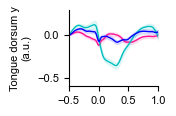

In [3]:
HS=45
syllables=["du", "ga", "gu"]
colors=["deeppink", "c", "blue"]
feature="Tongue dorsum y"
sheet_name = 'Ext. Fig. 2a'
save_path=clean_data_path + f"/figures_R3/{sheet_name}.pdf"

plot_akt_feature_from_source(
    sheet_name=sheet_name,
    syllables=syllables,
    colors=colors,
    feature=feature,
    save_path=save_path
)

# Ext. Fig. 2d

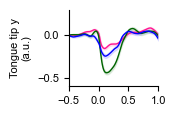

In [4]:
HS=45
syllables = ['du','da','gu']
colors = ['deeppink','darkgreen','blue']
feature="Tongue tip y"
sheet_name = 'Ext. Fig. 2d'
save_path=clean_data_path + f"/figures_R3/{sheet_name}.pdf"

plot_akt_feature_from_source(
    sheet_name=sheet_name,
    syllables=syllables,
    colors=colors,
    feature=feature,
    save_path=save_path
)

# Ext. Fig. 2g

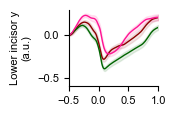

In [5]:
HS=50
syllables = ['ba', 'da', 'du']
colors = ['darkred','darkgreen','deeppink']
feature="Lower incisor y"
sheet_name = 'Ext. Fig. 2g'
save_path=clean_data_path + f"/figures_R3/{sheet_name}.pdf"

plot_akt_feature_from_source(
    sheet_name=sheet_name,
    syllables=syllables,
    colors=colors,
    feature=feature,
    save_path=save_path
)

# Ext. Fig. 2j

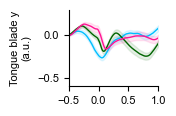

In [6]:
HS=50
syllables = ['bu', 'da', 'du']
colors = ['deepskyblue','darkgreen','deeppink']
feature="Tongue blade y"
sheet_name = 'Ext. Fig. 2j'
save_path=clean_data_path + f"/figures_R3/{sheet_name}.pdf"

plot_akt_feature_from_source(
    sheet_name=sheet_name,
    syllables=syllables,
    colors=colors,
    feature=feature,
    save_path=save_path
)

# Ext. Fig. 2l

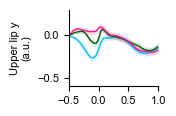

In [7]:
HS=50
syllables = ['bu', 'da', 'du']
colors = ['deepskyblue','darkgreen','deeppink']
feature="Upper lip y"
sheet_name = 'Ext. Fig. 2l'
save_path=clean_data_path + f"/figures_R3/{sheet_name}.pdf"

plot_akt_feature_from_source(
    sheet_name=sheet_name,
    syllables=syllables,
    colors=colors,
    feature=feature,
    save_path=save_path
)

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def ERP_cross_modal(HS, pidx, syllable_list, color_list, sheet_name):
    color_dict = {}
    for syllable in syllable_list:
        for condition in ["overt", "covert"]:
            if condition == "overt":
                color_dict[f"{condition}_{syllable}"] = color_list[0]
            elif condition == "covert":
                color_dict[f"{condition}_{syllable}"] = color_list[1]

    plt.rcParams["font.family"] = "Arial"
    plt.rcParams["font.size"] = 8

    # ==========================
    # Read the Source Data workbook.
    # ==========================
    source_data = pd.read_excel(
        clean_data_path + "/Source_Data.xlsx",
        sheet_name=sheet_name
    )

    for syllable in syllable_list:
        print(syllable)

        fig, ax = plt.subplots(figsize=(1.5, 1.2))
        for condition in ["overt", "covert"]:

            label = f"{condition}_{syllable}"

            df = source_data[source_data["Label"] == label]

            # Arrange the data as trials by time points.
            pivot = df.pivot(
                index="Trial",
                columns="Time (s)",
                values="Z-score"
            )

            time = pivot.columns.values.astype(float)

            data = pivot.values

            mean = data.mean(axis=0)
            sem = data.std(axis=0, ddof=1) / np.sqrt(data.shape[0])

            ax.fill_between(
                time,
                mean - sem,
                mean + sem,
                color=color_dict[label],
                alpha=0.15,
            )

            ax.plot(
                time,
                mean,
                color=color_dict[label],
                linewidth=1,
                label=condition,
            )

        ax.set_xlim(-0.5, 1)
        ax.set_ylim(-1, 1.4)

        ax.set_xticks([-0.5, 0, 0.5, 1])
        ax.set_yticks([0, 1])

        ax.set_xlabel("")
        ax.set_ylabel("")

        ax.spines["right"].set_visible(False)
        ax.spines["top"].set_visible(False)

        from scipy.stats import mannwhitneyu

        threshold = 0.05 / 3

        p_values = []

        for t in time:

            overt = source_data[
                (source_data["Condition"] == "overt") &
                (source_data["Syllable"] == syllable) &
                (source_data["Time (s)"] == t)
            ]["Z-score"]

            covert = source_data[
                (source_data["Condition"] == "covert") &
                (source_data["Syllable"] == syllable) &
                (source_data["Time (s)"] == t)
            ]["Z-score"]

            _, p = mannwhitneyu(overt, covert)

            p_values.append(p)

        sig_time = time[np.array(p_values) < threshold]

        ax.scatter(
            sig_time,
            np.repeat(-0.7, len(sig_time)),
            s=2,
            color="k"
        )

        plt.tight_layout()

        plt.savefig(
            clean_data_path + f"/figures_R3/{sheet_name}_{syllable}.pdf",
            dpi=300,
            transparent=True,
            bbox_inches="tight",
        )

        plt.show()

# Ext. Fig. 2c

du


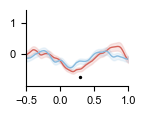

ga


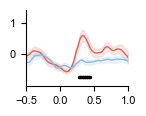

gu


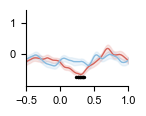

In [9]:
HS = 45
pidx = 37
syllable_list = ["du", "ga", "gu"]
color_list = ['#D5645B','#88BBDF']
sheet_name = "Ext. Fig. 2c"

ERP_cross_modal(HS, pidx, syllable_list, color_list, sheet_name)

# Ext. Fig. 2f

gu


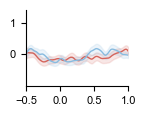

da


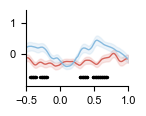

du


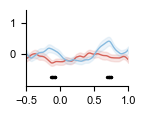

In [10]:
HS = 45
pidx = 78
syllable_list = ['gu','da','du']
color_list = ['#D5645B','#88BBDF']
sheet_name = "Ext. Fig. 2f"

ERP_cross_modal(HS, pidx, syllable_list, color_list, sheet_name)

# Ext. Fig. 2i

ba


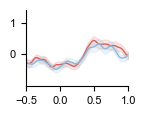

da


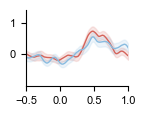

du


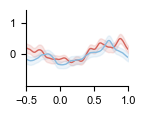

In [11]:
HS = 50
pidx = 61
syllable_list = ['ba','da','du']
color_list = ['#D5645B','#88BBDF']
sheet_name = "Ext. Fig. 2i"

ERP_cross_modal(HS, pidx, syllable_list, color_list, sheet_name)

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def ERP_cross_syllable(HS, pidx, syllable_list, color_list, sheet_name, sig_flag):
    color_dict = {}
    for condition in ["overt", "covert"]:
        for i, syllable in enumerate(syllable_list):
            color_dict[f"{condition}_{syllable}"] = color_list[i]

    plt.rcParams["font.family"] = "Arial"
    plt.rcParams["font.size"] = 8

    # ==========================
    # Read the Source Data workbook.
    # ==========================
    source_data = pd.read_excel(
        clean_data_path + "/Source_Data.xlsx",
        sheet_name=sheet_name
    )

    for condition in ["overt", "covert"]:
        print(condition)

        fig, ax = plt.subplots(figsize=(1.5, 1.2))
        for syllable in syllable_list:
            label = f"{condition}_{syllable}"

            df = source_data[source_data["Label"] == label]

            # Arrange the data as trials by time points.
            pivot = df.pivot(
                index="Trial",
                columns="Time (s)",
                values="Z-score"
            )

            time = pivot.columns.values.astype(float)

            data = pivot.values

            mean = data.mean(axis=0)
            sem = data.std(axis=0, ddof=1) / np.sqrt(data.shape[0])

            ax.fill_between(
                time,
                mean - sem,
                mean + sem,
                color=color_dict[label],
                alpha=0.1,
            )

            ax.plot(
                time,
                mean,
                color=color_dict[label],
                linewidth=1,
                label=condition,
            )

        ax.set_xlim(-0.5, 1)
        ax.set_ylim(-1, 1.4)

        ax.set_xticks([-0.5, 0, 0.5, 1])
        ax.set_yticks([0, 1])

        ax.set_xlabel("")
        ax.set_ylabel("")

        ax.spines["right"].set_visible(False)
        ax.spines["top"].set_visible(False)

        from scipy.stats import kruskal

        threshold = 0.05

        p_values = []

        for t in time:

            groups = []

            for syllable in syllable_list:

                values = source_data[
                    (source_data["Condition"] == condition) &
                    (source_data["Syllable"] == syllable) &
                    (source_data["Time (s)"] == t)
                ]["Z-score"].values

                groups.append(values)

            _, p = kruskal(*groups)
            p_values.append(p)

        sig_time = time[np.array(p_values) < threshold]
        
        if sig_flag[condition] == 1:
            ax.scatter(
                sig_time,
                np.repeat(-0.8, len(sig_time)),
                s=2,
                color="k"
            )
        
        plt.tight_layout()

        plt.savefig(
            clean_data_path + f"/figures_R3/{sheet_name}_{condition}.pdf",
            dpi=300,
            transparent=True,
            bbox_inches="tight",
        )

        plt.show()

# Ext. Fig. 2b

overt


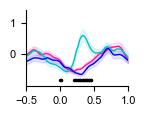

covert


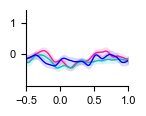

In [13]:
HS = 45
pidx = 37
color_list = ['deeppink','c','blue']
syllable_list = ['du','ga','gu']
sheet_name = "Ext. Fig. 2b"
sig_flag = {
    'overt':1,
    'covert':0
}

ERP_cross_syllable(HS, pidx, syllable_list, color_list, sheet_name, sig_flag)

# Ext. Fig. 2e

overt


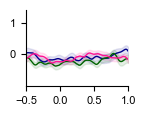

covert


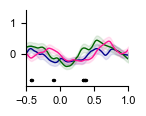

In [14]:
HS = 45
pidx = 78
color_list = ['darkblue','darkgreen','deeppink']
syllable_list = ['gu','da', 'du']
sheet_name = "Ext. Fig. 2e"
sig_flag = {
    'overt':0,
    'covert':1
}

ERP_cross_syllable(HS, pidx, syllable_list, color_list, sheet_name, sig_flag)

# Ext. Fig. 2k-m

overt


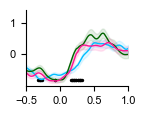

covert


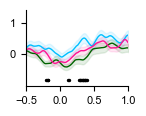

In [15]:
HS = 50
pidx = 85
color_list = ['deepskyblue','darkgreen','deeppink']
syllable_list = ['bu', 'da','du']
sheet_name = "Ext. Fig. 2k-m"
sig_flag = {
    'overt':1,
    'covert':1
}

ERP_cross_syllable(HS, pidx, syllable_list, color_list, sheet_name, sig_flag)

# Ext. Fig. 2h

overt


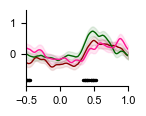

covert


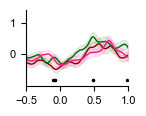

In [16]:
HS = 50
pidx = 61
color_list = ['darkred','darkgreen','deeppink']
syllable_list = ['ba', 'da','du']
sheet_name = "Ext. Fig. 2h"
sig_flag = {
    'overt':1,
    'covert':1
}

ERP_cross_syllable(HS, pidx, syllable_list, color_list, sheet_name, sig_flag)